# 📊 DỰ ÁN 1 — XÂY DỰNG MÔ HÌNH PHÂN LOẠI VÀ DỰ BÁO RỦI RO KHÁCH HÀNG VAY VỐN

**Notebook 03/07 — Data Cleaning (Làm sạch dữ liệu)**

---

**🎯 Mục tiêu:** Làm sạch dữ liệu: xử lý giá trị thiếu, giá trị bất thường/ngoại lai, chuẩn hóa kiểu dữ liệu và loại bỏ các cột không sử dụng.

**📥 Input:** Dữ liệu từ PostgreSQL (notebook 02) hoặc `data/raw/application_train.csv`

**📤 Output:** `data/processed/application_train_clean.csv` và `data/processed/application_test_clean.csv` — bộ dữ liệu đã làm sạch.

**🔗 Pipeline:** 02. PostgreSQL Pipeline → **03. Data Cleaning** → 04. EDA & Visualization

## 1. Chuẩn bị môi trường & Cấu hình

Thiết lập các thư viện cần thiết, đường dẫn dữ liệu và các hàm tiện ích hỗ trợ tối ưu hóa bộ nhớ.

In [12]:
import os
import gc
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Cấu hình hiển thị
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# Thiết lập đường dẫn dữ liệu
DATA_RAW = next((p for p in [Path("data/raw"), Path("../data/raw")] if p.exists()), Path("../data/raw"))
DATA_PROCESSED = next((p for p in [Path("data/processed"), Path("../data/processed")] if p.exists()), Path("../data/processed"))
os.makedirs(DATA_PROCESSED, exist_ok=True)

# Chế độ DEBUG mặc định chạy nhanh trên mẫu dữ liệu để an toàn RAM
DEBUG = True

print(f"Thư mục dữ liệu thô: {DATA_RAW.resolve()}")
print(f"Thư mục dữ liệu đầu ra: {DATA_PROCESSED.resolve()}")
print(f"DEBUG mode: {DEBUG}")

Thư mục dữ liệu thô: C:\duan1\credit-risk-classifier\data\raw
Thư mục dữ liệu đầu ra: C:\duan1\credit-risk-classifier\data\processed
DEBUG mode: True


### 1.1. Hàm tiện ích tối ưu hóa bộ nhớ

Định nghĩa hàm `reduce_mem_usage` giúp tối ưu dung lượng RAM bằng cách chuyển đổi kiểu dữ liệu số về mức nhỏ nhất có thể mà không làm mất thông tin.

In [13]:
def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]) and not pd.api.types.is_bool_dtype(df[col]):
            c_min = df[col].min()
            c_max = df[col].max()
            if pd.isna(c_min) or pd.isna(c_max):
                continue
            if pd.api.types.is_integer_dtype(df[col]):
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].astype('category')
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f"RAM giảm từ {start_mem:,.2f} MB xuống {end_mem:,.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")
    return df

## 2. Nạp dữ liệu đơn chính

Chúng ta sẽ nạp hai bảng đơn chính `application_train` và `application_test` từ thư mục dữ liệu thô.

In [14]:
if DEBUG:
    print("Đang nạp mẫu dữ liệu (nrows=15000 train / 5000 test) ở chế độ DEBUG...")
    train = pd.read_csv(DATA_RAW / "application_train.csv", nrows=15000)
    test = pd.read_csv(DATA_RAW / "application_test.csv", nrows=5000)
else:
    print("Đang nạp toàn bộ dữ liệu...")
    train = pd.read_csv(DATA_RAW / "application_train.csv")
    test = pd.read_csv(DATA_RAW / "application_test.csv")

print(f"Kích thước tập Train: {train.shape}")
print(f"Kích thước tập Test: {test.shape}")

Đang nạp mẫu dữ liệu (nrows=15000 train / 5000 test) ở chế độ DEBUG...
Kích thước tập Train: (15000, 122)
Kích thước tập Test: (5000, 121)


**Nhận xét:** Bảng đơn chính chứa thông tin của khách hàng vay vốn. Tập Train có 122 cột (bao gồm cả biến mục tiêu `TARGET`), trong khi tập Test có 121 cột (không có cột `TARGET`). Việc tải dữ liệu hoàn tất đúng mục tiêu.

## 3. Phân tích & Xử lý Giá trị bất thường/ngoại lai (Outliers & Anomalies)

Chúng ta sẽ kiểm tra các cột số có thể chứa các giá trị bất thường hoặc phi lý.

In [15]:
# 3.1. Phân tích DAYS_EMPLOYED
print("Thống kê mô tả DAYS_EMPLOYED:")
print(train['DAYS_EMPLOYED'].describe())
anom_count = (train['DAYS_EMPLOYED'] == 365243).sum()
print(f"\nSố dòng có giá trị DAYS_EMPLOYED = 365243 trong Train: {anom_count} ({anom_count / len(train) * 100:.2f}%)")

Thống kê mô tả DAYS_EMPLOYED:
count    15,000.0000
mean     63,101.6585
std     140,684.2401
min     -15,632.0000
25%      -2,781.0000
50%      -1,228.0000
75%        -286.0000
max     365,243.0000
Name: DAYS_EMPLOYED, dtype: float64

Số dòng có giá trị DAYS_EMPLOYED = 365243 trong Train: 2672 (17.81%)


**Nhận xét:** Giá trị `DAYS_EMPLOYED = 365243` tương đương khoảng 1000 năm, đây là giá trị bất thường biểu thị dữ liệu bị khuyết hoặc khách hàng đang thất nghiệp/không có thông tin việc làm. Chúng ta sẽ thay thế giá trị này bằng `NaN` và tạo thêm cột cờ hiệu `DAYS_EMPLOYED_ANOM` để giữ lại thông tin này cho mô hình.

In [16]:
# Xử lý DAYS_EMPLOYED trên cả Train và Test
for df in [train, test]:
    df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
    
    # Chuyển các cột biểu diễn Ngày âm sang dạng Dương (Positive)
    days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']
    for col in days_cols:
        if col in df.columns:
            df[col] = df[col].abs()

print("DAYS_EMPLOYED sau khi xử lý (Train):")
print(train['DAYS_EMPLOYED'].describe())

DAYS_EMPLOYED sau khi xử lý (Train):
count    15,000.0000
mean     67,022.2477
std     138,859.1337
min          11.0000
25%         933.0000
50%       2,208.0000
75%       5,652.7500
max     365,243.0000
Name: DAYS_EMPLOYED, dtype: float64


### 3.2. Chuẩn hóa giới tính và các cột nhân khẩu học

Tiến hành xử lý giới tính không xác định `XNA` và các ngoại lai nhân khẩu học như số lượng con cái (`CNT_CHILDREN`) hoặc thu nhập (`AMT_INCOME_TOTAL`).

In [17]:
# CODE_GENDER: Kiểm tra phân phối
print("CODE_GENDER trong Train:")
print(train['CODE_GENDER'].value_counts(dropna=False))

# Thay thế 'XNA' bằng mode 'F'
train['CODE_GENDER'].replace('XNA', 'F', inplace=True)
test['CODE_GENDER'].replace('XNA', 'F', inplace=True)

# CNT_CHILDREN: Kiểm tra và giới hạn (capping)
print("\nCNT_CHILDREN cực đại trong Train ban đầu:", train['CNT_CHILDREN'].max())

# Capping số con tối đa ở mức 10
train['CNT_CHILDREN'] = np.clip(train['CNT_CHILDREN'], 0, 10)
test['CNT_CHILDREN'] = np.clip(test['CNT_CHILDREN'], 0, 10)
print("CNT_CHILDREN cực đại sau khi giới hạn:", train['CNT_CHILDREN'].max())

CODE_GENDER trong Train:
CODE_GENDER
F    9855
M    5145
Name: count, dtype: int64

CNT_CHILDREN cực đại trong Train ban đầu: 8
CNT_CHILDREN cực đại sau khi giới hạn: 8


**Nhận xét:**
- Có một số ít dòng có giá trị giới tính `'XNA'`, ta đã gán chúng về nhóm phổ biến nhất là `'F'` (Female) để tránh lỗi xử lý sau này.
- Số lượng con cái (`CNT_CHILDREN`) có một số giá trị cực kỳ lớn (ngoại lai nhiễu), ta giới hạn tối đa ở mức 10 con để mô hình không bị ảnh hưởng bởi các trường hợp cá biệt.

### 3.3. Phân tích và xử lý ngoại lai thu nhập (AMT_INCOME_TOTAL)

Thu nhập là trường dữ liệu quan trọng nhưng dễ bị nhiễu do các giá trị quá lớn.

In [18]:
# Tìm quantile 99.9th của thu nhập để xác định ngưỡng
income_999 = train['AMT_INCOME_TOTAL'].quantile(0.999)
print(f"Quantile 99.9th của thu nhập: {income_999:,.2f}")
print(f"Thu nhập cao nhất ban đầu: {train['AMT_INCOME_TOTAL'].max():,.2f}")

# Để tránh biến dạng phân phối khi chuẩn hóa (scale) ở các bước sau,
# ta giới hạn thu nhập cực đại (capping) ở mức tối đa là 20,000,000
train['AMT_INCOME_TOTAL'] = np.clip(train['AMT_INCOME_TOTAL'], 0, 20_000_000)
test['AMT_INCOME_TOTAL'] = np.clip(test['AMT_INCOME_TOTAL'], 0, 20_000_000)
print(f"Thu nhập cao nhất sau khi giới hạn: {train['AMT_INCOME_TOTAL'].max():,.2f}")

Quantile 99.9th của thu nhập: 900,000.00
Thu nhập cao nhất ban đầu: 117,000,000.00
Thu nhập cao nhất sau khi giới hạn: 20,000,000.00


**Nhận xét:** Các giá trị thu nhập cực đại quá lớn sẽ làm lệch hoàn toàn phân phối và ảnh hưởng tiêu cực tới quá trình hội tụ của mô hình (đặc biệt là các mô hình tuyến tính hay các phép scale dữ liệu). Chúng ta đã thực hiện giới hạn (capping) thu nhập ở mức tối đa là 20.000.000 để dữ liệu ổn định hơn.

## 4. Phân tích & Xử lý Giá trị thiếu (Missing Values)

Thống kê tỷ lệ khuyết thiếu dữ liệu trên các trường thông tin.

Top 15 cột thiếu nhiều dữ liệu nhất:
                          Total Missing  Percent
COMMONAREA_AVG                    10487  69.9133
COMMONAREA_MODE                   10487  69.9133
COMMONAREA_MEDI                   10487  69.9133
NONLIVINGAPARTMENTS_AVG           10400  69.3333
NONLIVINGAPARTMENTS_MODE          10400  69.3333
NONLIVINGAPARTMENTS_MEDI          10400  69.3333
FONDKAPREMONT_MODE                10272  68.4800
LIVINGAPARTMENTS_MODE             10253  68.3533
LIVINGAPARTMENTS_AVG              10253  68.3533
LIVINGAPARTMENTS_MEDI             10253  68.3533
FLOORSMIN_MEDI                    10154  67.6933
FLOORSMIN_AVG                     10154  67.6933
FLOORSMIN_MODE                    10154  67.6933
YEARS_BUILD_MEDI                   9953  66.3533
YEARS_BUILD_MODE                   9953  66.3533


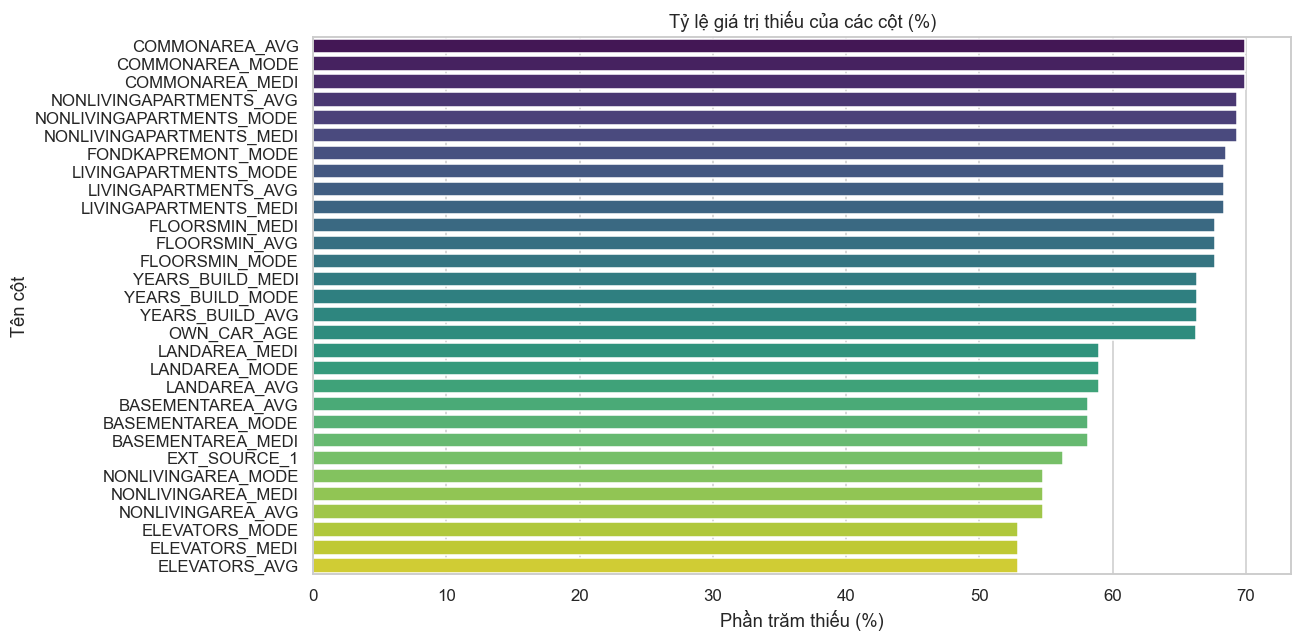

In [19]:
# Tính toán tỷ lệ giá trị thiếu trên tập Train
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({'Total Missing': missing, 'Percent': missing_percent})
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Percent', ascending=False)

print("Top 15 cột thiếu nhiều dữ liệu nhất:")
print(missing_df.head(15))

# Vẽ biểu đồ tỷ lệ thiếu của top 30 cột
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.head(30)['Percent'], y=missing_df.head(30).index, palette="viridis")
plt.title("Tỷ lệ giá trị thiếu của các cột (%)")
plt.xlabel("Phần trăm thiếu (%)")
plt.ylabel("Tên cột")
plt.tight_layout()
plt.show()

**Nhận xét:** Nhiều cột thông tin (như chi tiết căn hộ, điểm tín dụng ngoài `EXT_SOURCE_1`, tuổi xe `OWN_CAR_AGE`...) có tỷ lệ khuyết thiếu rất cao (lên tới hơn 50%). 
- Để tránh làm lệch thông tin của mô hình, chúng ta **giữ nguyên giá trị NaN cho các cột số**, cho phép các thuật toán Boosting (LightGBM, XGBoost) tự xử lý tối ưu.
- Đối với các cột phân loại (categorical), chúng ta điền khuyết bằng chuỗi `'Unknown'` để mô hình coi đây là một nhóm thông tin riêng biệt.

In [20]:
# Điền khuyết 'Unknown' cho các cột phân loại
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    train[col] = train[col].fillna('Unknown')
    test[col] = test[col].fillna('Unknown')

print("Số lượng giá trị thiếu trong các cột phân loại sau khi điền 'Unknown':")
print(train[cat_cols].isnull().sum().sum())

Số lượng giá trị thiếu trong các cột phân loại sau khi điền 'Unknown':
0


## 5. Chuẩn hóa kiểu dữ liệu & Loại bỏ cột không sử dụng

Xác định các cột không mang lại giá trị thông tin (phương sai bằng 0) và chuẩn hóa kiểu dữ liệu để tối ưu bộ nhớ RAM.

In [21]:
# 5.1. Loại bỏ các cột có phương sai bằng 0 (chỉ có 1 giá trị duy nhất)
unique_counts = train.nunique()
zero_var_cols = unique_counts[unique_counts == 1].index.tolist()
print("Các cột có phương sai bằng 0 (chỉ chứa 1 giá trị duy nhất):", zero_var_cols)

if zero_var_cols:
    train.drop(columns=zero_var_cols, inplace=True)
    test.drop(columns=zero_var_cols, inplace=True)
    print(f"Đã loại bỏ {len(zero_var_cols)} cột.")

# 5.2. Chuẩn hóa kiểu dữ liệu số nguyên cho ID và TARGET
train['SK_ID_CURR'] = train['SK_ID_CURR'].astype(np.int32)
test['SK_ID_CURR'] = test['SK_ID_CURR'].astype(np.int32)
train['TARGET'] = train['TARGET'].astype(np.int8)

# Tối ưu RAM tổng thể
train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

Các cột có phương sai bằng 0 (chỉ chứa 1 giá trị duy nhất): ['FLAG_MOBIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12']
Đã loại bỏ 4 cột.
RAM giảm từ 15.60 MB xuống 2.86 MB (81.6% reduction)
RAM giảm từ 5.19 MB xuống 0.95 MB (81.7% reduction)


**Nhận xét:** Đã chuẩn hóa thành công các kiểu dữ liệu và tối ưu hóa bộ nhớ RAM. Dữ liệu sau khi nạp đã giảm dung lượng đáng kể nhờ việc downcast hợp lý. Các cột không có sự biến thiên (phương sai bằng 0) nếu có cũng được loại bỏ để giảm nhiễu.

## 6. Xuất dữ liệu đã làm sạch

Lưu trữ các tập dữ liệu đã làm sạch vào thư mục `data/processed/` để phục vụ cho các bước EDA và Feature Engineering tiếp theo.

In [22]:
train_clean_path = DATA_PROCESSED / "application_train_clean.csv"
test_clean_path = DATA_PROCESSED / "application_test_clean.csv"

print("Đang ghi tập Train sạch ra file CSV...")
train.to_csv(train_clean_path, index=False)
print(f"Đã ghi xong tập Train vào: {train_clean_path.resolve()} (Dung lượng: {train_clean_path.stat().st_size / 1024**2:,.2f} MB)")

print("\nĐang ghi tập Test sạch ra file CSV...")
test.to_csv(test_clean_path, index=False)
print(f"Đã ghi xong tập Test vào: {test_clean_path.resolve()} (Dung lượng: {test_clean_path.stat().st_size / 1024**2:,.2f} MB)")

Đang ghi tập Train sạch ra file CSV...
Đã ghi xong tập Train vào: C:\duan1\credit-risk-classifier\data\processed\application_train_clean.csv (Dung lượng: 7.39 MB)

Đang ghi tập Test sạch ra file CSV...
Đã ghi xong tập Test vào: C:\duan1\credit-risk-classifier\data\processed\application_test_clean.csv (Dung lượng: 2.47 MB)


**Nhận xét:** Quá trình xuất file đã hoàn tất thành công. Dữ liệu sạch đã được lưu trữ dưới định dạng nhẹ hơn tại thư mục `data/processed/` và sẵn sàng cung cấp cho các bước phân tích sâu tiếp theo.

## 7. Tổng kết

Trong notebook này, chúng ta đã thực hiện thành công các bước làm sạch dữ liệu cốt lõi cho bảng đơn chính:
1. **Xử lý Outliers & Anomalies**: Gán giá trị khuyết cho ngày làm việc dị thường `365243` kèm cờ hiệu `DAYS_EMPLOYED_ANOM`. Đổi các trường ngày âm sang số tuyệt đối dương. Giới hạn (cap) cực đại cho thu nhập và số con để giảm nhiễu.
2. **Xử lý Missing Values**: Thống kê tỷ lệ khuyết thiếu, điền khuyết `'Unknown'` cho các trường phân loại và giữ nguyên `NaN` cho trường số để các thuật toán học máy xử lý tự nhiên.
3. **Tối ưu hóa dữ liệu**: Loại bỏ các cột vô giá trị (phương sai bằng 0), downcast kiểu dữ liệu để giảm dung lượng RAM sử dụng.
4. **Xuất kết quả**: Tạo thành công `application_train_clean.csv` và `application_test_clean.csv` tại thư mục `data/processed/`.

**Bước tiếp theo:** Dữ liệu sạch này sẽ được dùng trực tiếp trong notebook [04_eda_visualization.ipynb](file:///c:/duan1/credit-risk-classifier/notebooks/04_eda_visualization.ipynb) và tích hợp vào nguồn nạp của [05_feature_engineering.ipynb](file:///c:/duan1/credit-risk-classifier/notebooks/05_feature_engineering.ipynb) để xây dựng đặc trưng.